#### Assignment 4

Compared to other classifiers, Naïve Bayes is straightforward to understand as long as we're
comfortable with the naïve assumption that predictors are mutually independent, given the label.
Calculating the predicted probabilities is straightforward, as only basic summary statistics such as
counts, means, and standard deviations are needed. Plus, Naïve Bayes is known for being a quick and
resource-efficient choice because it doesn't require multiple iterations and doesn't demand much
memory or storage. This makes Naïve Bayes a reliable and viable option for many situations.
Naïve Bayes can handle many predictors easily, but it doesn't automatically identify the most important

ones. We might consider using forward or backward selection, but then we face the question: how do
we determine which predictors are truly the most valuable? In complex situations, trying all possible
subsets could be a viable approach. This method helps us find the set of predictors that produces the
best-performing Naïve Bayes model.

While we might not always agree on which model is the "best," we all share the goal of choosing one
that generally performs well at predicting labels. To help us with this, we'll explore common measures
such as overall accuracy, the area under the curve, and root-mean-square error, which give us a good
idea of each model's performance. We'll start by identifying the predictor sets that perform the best for each of these measures. Next, we'll look at how each model handles different label categories by
checking local classification accuracy. Ultimately, we'll pick the simplest model that still delivers strong results across all categories, helping us find a nice balance between accuracy and simplicity.

You will use the approach outlined above to recommend a Naïve Bayes model trained on the WHAS500
Data (whas500.csv) from the Worcester Heart Attack Study. The label variable lenfol records the
number of days since the patient's last follow-up, starting from the date of their first hospital admission.

You will organize its values into four chronological categories: (1) lenfol  30, (2) 30 < lenfol  180, (3)
180 < lenfol  540, and (4) 540 < lenfol.

You will consider the following eight categorical predictors.

1. afb: Atrial Fibrillation, 0 = No, 1 = Yes
2. av3: Complete Heart Block, 0 = No, 1 = Yes
3. chf: Congestive Heart Complications, 0 = No, 1 = Yes
4. cvd: History of Cardiovascular Disease, 0 = No, 1 = Yes
5. gender: Gender, 0 = Male, 1 = Female
6. miord: Myocardial Infarction Order, 0 = First, 1 = Recurrent
7. mitype: Myocardial Infarction Type, 0 = non-Q-wave, 1 = Q-wave
8. sho: Cardiogenic Shock, 0 = No, 1 = Yes

You will also examine five continuous predictors. Instead of using their original values, you'll partition them into four bins (boundaries provided in parentheses) and use the binned variables for training.

1. age: Age at Hospital Admission in number of years (67.5, 72.5, and 85.5)
2. bmi: Body Mass Index in kilograms per square meter (23.2982, 24.2238, and 28.5612)
3. diasbp: Initial Diastolic Blood Pressure in mmHg (60.5, 76.5, and 97.5)
4. hr: Initial Heart Rate in number of beats per minute (67.5, 83.5, and 102.5)
5. sysbp: Initial Systolic Blood Pressure in mmHg (106.5, 136.5, and 185.0)

The label category we predict should be the one with the highest predicted probability. In case of a tie
where multiple categories share the same top probability, select the category that comes first lexically.
If you come across any cells with zero counts (a.k.a. empty cells) in the crosstabulation tables, set the
Alpha parameter to the reciprocal of twice the number of Label categories. If not, you must leave the
parameter at zero.
With 13 predictors, you'll be training 8,191 models. Depending on your computer, this might take
anywhere from thirty minutes to an hour. So, please be patient and record performance metrics!


In [87]:
# imports
import pandas as pd
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, root_mean_squared_error
from sklearn.metrics import roc_auc_score
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [88]:
# dataset
whas = pd.read_csv("whas500.csv")
whas.head()

,id,age,gender,hr,sysbp,diasbp,bmi,cvd,afb,sho,...,miord,mitype,year,admitdate,disdate,fdate,los,dstat,lenfol,fstat
0,1,83,0,89,152,78,25.54051,1,1,0,...,1,0,1,13-01-1997,18-01-1997,31-12-2002,5,0,2178,0
1,2,49,0,84,120,60,24.02398,1,0,0,...,0,1,1,19-01-1997,24-01-1997,31-12-2002,5,0,2172,0
2,3,70,1,83,147,88,22.14290,0,0,0,...,0,1,1,01-01-1997,06-01-1997,31-12-2002,5,0,2190,0
3,4,70,0,65,123,76,26.63187,1,0,0,...,0,1,1,17-02-1997,27-02-1997,11-12-1997,10,0,297,1
4,5,70,0,63,135,85,24.41255,1,0,0,...,0,1,1,01-03-1997,07-03-1997,31-12-2002,6,0,2131,0


In [89]:
# organize lenfol into categories
# (1) lenfol <= 30, (2) 30 < lenfol <= 180, (3) 180 < lenfol <= 540, and (4) 540 < lenfol.
def lenfol_category(lenfol):
    if lenfol <= 30:
        return 1
    elif lenfol <= 180:
        return 2
    elif lenfol <= 540:
        return 3
    else:
        return 4
whas["lenfol_cat"] = whas["lenfol"].apply(lenfol_category)
whas["lenfol_cat"] = whas["lenfol_cat"].astype("category")

In [90]:
# create continuous predictor bins
def create_bins(df, column, bins):
    df[column + "_bin"] = pd.cut(df[column], bins=bins)
    return df

# 1. age: Age at Hospital Admission in number of years (67.5, 72.5, and 85.5)
# 2. bmi: Body Mass Index in kilograms per square meter (23.2982, 24.2238, and 28.5612)
# 3. diasbp: Initial Diastolic Blood Pressure in mmHg (60.5, 76.5, and 97.5)
# 4. hr: Initial Heart Rate in number of beats per minute (67.5, 83.5, and 102.5)
# 5. sysbp: Initial Systolic Blood Pressure in mmHg (106.5, 136.5, and 185.0)

# create bins for age, bmi, diasbp, hr, and sysbp
whas = create_bins(whas, "age", [0, 67.5, 72.5, 85.5, float("inf")])
whas = create_bins(whas, "bmi", [0, 23.2982, 24.2238, 28.5612, float("inf")])
whas = create_bins(whas, "diasbp", [0, 60.5, 76.5, 97.5, float("inf")])
whas = create_bins(whas, "hr", [0, 67.5, 83.5, 102.5, float("inf")])
whas = create_bins(whas, "sysbp", [0, 106.5, 136.5, 185.0, float("inf")])

# make new columns categorical and get cat codes for nbayes
for col in ["age_bin", "bmi_bin", "diasbp_bin", "hr_bin", "sysbp_bin"]:
    whas[col] = whas[col].astype("category").cat.codes

whas.head()

,id,age,gender,hr,sysbp,diasbp,bmi,cvd,afb,sho,...,los,dstat,lenfol,fstat,lenfol_cat,age_bin,bmi_bin,diasbp_bin,hr_bin,sysbp_bin
0,1,83,0,89,152,78,25.54051,1,1,0,...,5,0,2178,0,4,2,2,2,2,2
1,2,49,0,84,120,60,24.02398,1,0,0,...,5,0,2172,0,4,0,1,0,2,1
2,3,70,1,83,147,88,22.14290,0,0,0,...,5,0,2190,0,4,1,0,2,1,2
3,4,70,0,65,123,76,26.63187,1,0,0,...,10,0,297,1,3,1,2,1,0,1
4,5,70,0,63,135,85,24.41255,1,0,0,...,6,0,2131,0,4,1,2,2,0,1


In [91]:
# Categorical predictors:
# 1. afb: Atrial Fibrillation, 0 = No, 1 = Yes
# 2. av3: Complete Heart Block, 0 = No, 1 = Yes
# 3. chf: Congestive Heart Complications, 0 = No, 1 = Yes
# 4. cvd: History of Cardiovascular Disease, 0 = No, 1 = Yes
# 5. gender: Gender, 0 = Male, 1 = Female
# 6. miord: Myocardial Infarction Order, 0 = First, 1 = Recurrent
# 7. mitype: Myocardial Infarction Type, 0 = non-Q-wave, 1 = Q-wave
# 8. sho: Cardiogenic Shock, 0 = No, 1 = Yes
whas_bayes = whas.copy()

predictor_columns = ["afb", "av3", "chf", "cvd", "gender", "miord", "mitype", "sho", "lenfol_cat", "age_bin", "bmi_bin", "diasbp_bin", "hr_bin", "sysbp_bin"]
# only keep categorical predictors, target variable and the binned continuous predictors
whas_bayes = whas_bayes[predictor_columns]

In [92]:
# check for zero counts in contingency tables for each predictor vs the target
# to deetermine if we need to use alpha = 0.125 for smoothing in the Naive Bayes model

predictors = ["afb", "av3", "chf", "cvd", "gender", "miord", "mitype", "sho", 
              "age_bin", "bmi_bin", "diasbp_bin", "hr_bin", "sysbp_bin"]

zero_found = False
for p in predictors:
    # Create a contingency table for each predictor vs the target
    ct = pd.crosstab(whas_bayes[p], whas_bayes["lenfol_cat"])
    if (ct == 0).any().any():
        print(f"Zero count found in predictor: {p}")
        zero_found = True

if zero_found:
    alpha_value = 1 / (2 * 4) # 0.125
    print(f"Zero cells found. Using Alpha = {alpha_value}")
else:
    alpha_value = 0.0
    print("No zero cells found. Using Alpha = 0.0")

No zero cells found. Using Alpha = 0.0


In [93]:
# run a naive bayes classifier on every subset of predictors
# and measure RASE, AUC, and accuracy
def evaluate_model(X, y):
            model = CategoricalNB(alpha=0.0)
            model.fit(X, y)
            y_pred = model.predict(X)
            y_prob = model.predict_proba(X)

            accuracy = accuracy_score(y, y_pred)
            auc = roc_auc_score(y, y_prob, multi_class='ovr')
            
            true_class_probs = y_prob[np.arange(len(y)), y.cat.codes]
            rase = root_mean_squared_error(np.ones(len(y)), true_class_probs)
            
            return accuracy, auc, rase

y = whas_bayes["lenfol_cat"]
predictor_columns = [p for p in predictor_columns if p != "lenfol_cat"]

results = []
for i in range(1, len(predictor_columns) + 1):
    for subset in combinations(predictor_columns, i):
        X = whas_bayes[list(subset)]
        accuracy, auc, rase = evaluate_model(X, y)
        
        results.append({
            "predictors": subset,
            "accuracy": accuracy,
            "auc": auc,
            "rase": rase
        })
results_df = pd.DataFrame(results)
results_df["n_predictors"] = results_df["predictors"].apply(len)
results_df.sort_values(by="auc", ascending=False, inplace=True)
results_df.head()

,predictors,accuracy,auc,rase,n_predictors
8077,"(av3, chf, miord, mitype, sho, age_bin, bmi_bin, diasbp_bin, hr_bin, sysbp_bin)",0.574,0.762569,0.577704,10
7712,"(av3, chf, mitype, sho, age_bin, bmi_bin, diasbp_bin, hr_bin, sysbp_bin)",0.568,0.762504,0.577600,9
8068,"(av3, chf, cvd, mitype, sho, age_bin, bmi_bin, diasbp_bin, hr_bin, sysbp_bin)",0.574,0.762456,0.578019,10
7932,"(afb, av3, chf, mitype, sho, age_bin, bmi_bin, diasbp_bin, hr_bin, sysbp_bin)",0.570,0.762215,0.578447,10
8076,"(av3, chf, gender, mitype, sho, age_bin, bmi_bin, diasbp_bin, hr_bin, sysbp_bin)",0.570,0.762067,0.578476,10


#### Question 1 (25 points)

Please consider plotting these three graphs together in a single chart, ideally arranged in a 3 x 1 layout:

the overall classification accuracy versus the number of predictors in a subset, the Root Average
Squared Error (RASE) versus the number of predictors, and the Area Under the Curve (AUC) versus the
number of predictors. What obvious insights might you discover from these graphs?


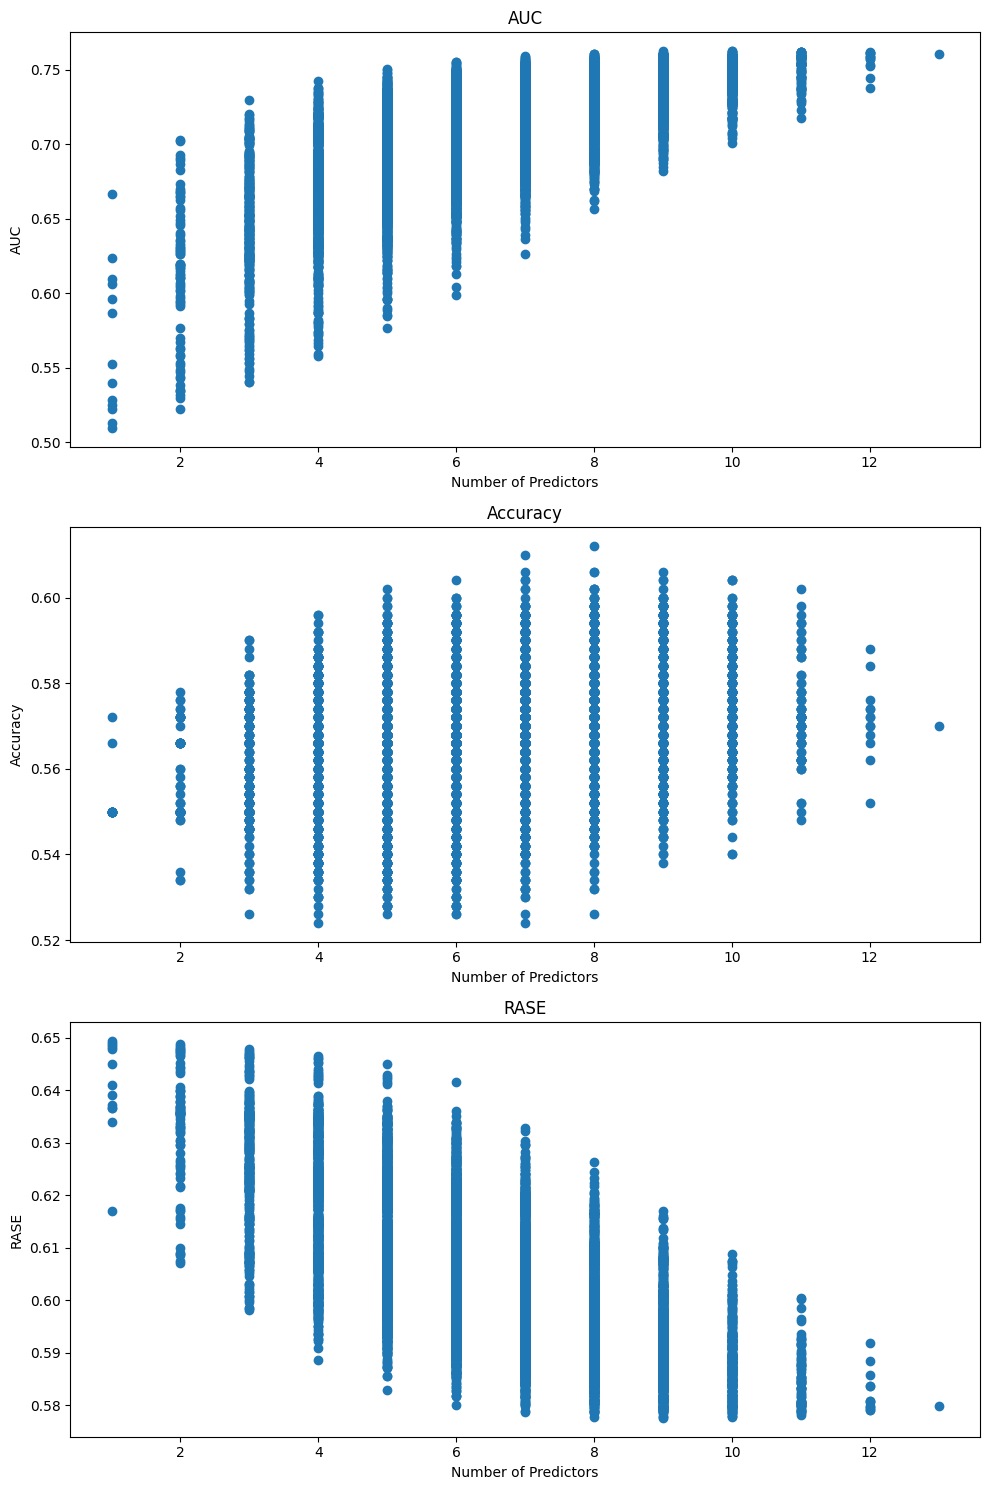

In [94]:
# create 3x1 layout of plots for accuracy, AUC, and RASE vs. number of predictors
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
# plot auc
axes[0].scatter(results_df["n_predictors"], results_df["auc"])
axes[0].set_xlabel("Number of Predictors")
axes[0].set_ylabel("AUC")
axes[0].set_title("AUC")
# plot accuracy
axes[1].scatter(results_df["n_predictors"], results_df["accuracy"])
axes[1].set_xlabel("Number of Predictors")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
# plot RASE
axes[2].scatter(results_df["n_predictors"], results_df["rase"])
axes[2].set_xlabel("Number of Predictors")
axes[2].set_ylabel("RASE")
axes[2].set_title("RASE")
plt.tight_layout()
plt.show()

#### Question 2 (25 points)

Could you please provide a table listing the optimal predictor subset for each of the three metrics, along
with the corresponding values for all three? It would be helpful to see which predictor subsets perform
best for each criterion. By the way, what predictors are included in all three top subsets?


In [100]:
# best subset of predictors by AUC
best_auc = results_df.sort_values(by="auc", ascending=False).iloc[0]

# best subset of predictors by accuracy
best_accuracy = results_df.sort_values(by="accuracy", ascending=False).iloc[0]

# best subset of predictors by RASE
best_rase = results_df.sort_values(by="rase", ascending=True).iloc[0]

# create a table comparing the best subsets of predictors for each metric
comparison_df = pd.DataFrame({
    "Metric": ["AUC", "Accuracy", "RASE"],
    "Accuracy": [best_auc["accuracy"], best_accuracy["accuracy"], best_rase["accuracy"]],
    "AUC": [best_auc["auc"], best_accuracy["auc"], best_rase["auc"]],
    "RASE": [best_auc["rase"], best_accuracy["rase"], best_rase["rase"]],
    "Best Predictors": [best_auc["predictors"], best_accuracy["predictors"], best_rase["predictors"]]
})
pd.set_option('display.max_colwidth', None)
display(comparison_df)

,Metric,Accuracy,AUC,RASE,Best Predictors
0,AUC,0.574,0.762569,0.577704,"(av3, chf, miord, mitype, sho, age_bin, bmi_bin, diasbp_bin, hr_bin, sysbp_bin)"
1,Accuracy,0.612,0.756297,0.578752,"(av3, chf, miord, sho, age_bin, bmi_bin, diasbp_bin, hr_bin)"
2,RASE,0.568,0.762504,0.577600,"(av3, chf, mitype, sho, age_bin, bmi_bin, diasbp_bin, hr_bin, sysbp_bin)"


In [101]:
# find predictors in all 3 subsets
best_auc_predictors = set(best_auc["predictors"])
best_accuracy_predictors = set(best_accuracy["predictors"])
best_rase_predictors = set(best_rase["predictors"])
common_predictors = best_auc_predictors.intersection(best_accuracy_predictors).intersection(best_rase_predictors)
print("Predictors in all 3 subsets:", common_predictors)    

Predictors in all 3 subsets: {'av3', 'chf', 'bmi_bin', 'sho', 'age_bin', 'hr_bin', 'diasbp_bin'}


#### Question 3 (25 points)

Please share the classification accuracy for each label category along with the Confusion Matrices of
your top-performing models in Question 2.


              precision    recall  f1-score   support

           1       0.43      0.49      0.46        57
           2       0.26      0.23      0.24        53
           3       0.40      0.15      0.22       115
           4       0.66      0.84      0.74       275

    accuracy                           0.57       500
   macro avg       0.44      0.43      0.41       500
weighted avg       0.53      0.57      0.53       500



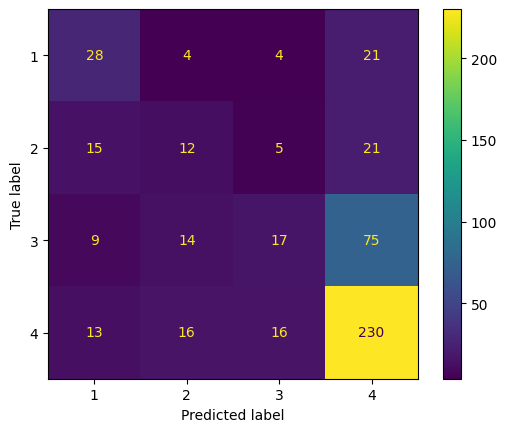

In [103]:
# best auc model:
# classification accuracy for each label category
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


best_auc_predictors = list(best_auc["predictors"])
X_best_auc = whas_bayes[best_auc_predictors]
model_best_auc = CategoricalNB(alpha=0.0)
model_best_auc.fit(X_best_auc, y)
print(classification_report(y, model_best_auc.predict(X_best_auc)))

# for reference:
# precision: TP / (TP + FP) - how many predicted positives are actually positive
# recall: TP / (TP + FN) - how many actual positives are correctly predicted

# confusion matrix for best auc model
cm = confusion_matrix(y, model_best_auc.predict(X_best_auc))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_best_auc.classes_)
disp.plot()


              precision    recall  f1-score   support

           1       0.48      0.54      0.51        57
           2       0.36      0.26      0.30        53
           3       0.56      0.16      0.24       115
           4       0.67      0.88      0.76       275

    accuracy                           0.61       500
   macro avg       0.52      0.46      0.45       500
weighted avg       0.59      0.61      0.56       500



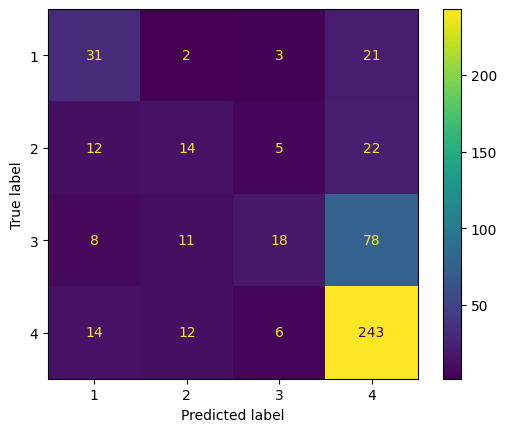

In [104]:
# best accuracy model:
best_accuracy_predictors = list(best_accuracy["predictors"])
X_best_accuracy = whas_bayes[best_accuracy_predictors]
model_best_accuracy = CategoricalNB(alpha=0.0)
model_best_accuracy.fit(X_best_accuracy, y)
print(classification_report(y, model_best_accuracy.predict(X_best_accuracy)))

# confusion matrix for best accuracy model
cm = confusion_matrix(y, model_best_accuracy.predict(X_best_accuracy))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_best_accuracy.classes_)
disp.plot()

              precision    recall  f1-score   support

           1       0.42      0.51      0.46        57
           2       0.28      0.25      0.26        53
           3       0.39      0.14      0.21       115
           4       0.66      0.82      0.73       275

    accuracy                           0.57       500
   macro avg       0.44      0.43      0.41       500
weighted avg       0.53      0.57      0.53       500



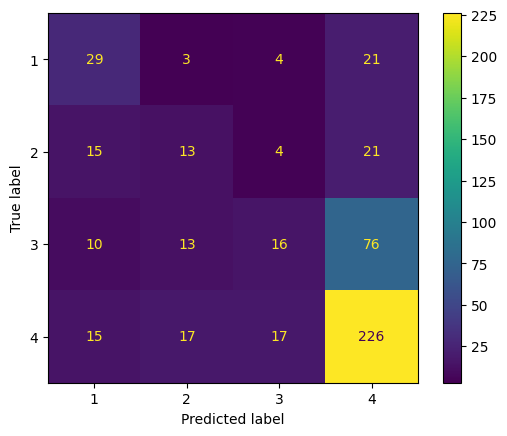

In [105]:
# best rase model:
best_rase_predictors = list(best_rase["predictors"])
X_best_rase = whas_bayes[best_rase_predictors]
model_best_rase = CategoricalNB(alpha=0.0)
model_best_rase.fit(X_best_rase, y)
print(classification_report(y, model_best_rase.predict(X_best_rase)))

# confusion matrix for best rase model
cm = confusion_matrix(y, model_best_rase.predict(X_best_rase))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_best_rase.classes_)
disp.plot()

#### Question 4 (25 points)

Based on your previous findings, which model will you ultimately recommend? Your objective is to
achieve acceptable classification accuracy across all label categories without compromising the model
metrics.